In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/sbi_features.csv")
print(df.head(15))
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())

          Date        Open        High         Low       Close   Adj Close  \
0   2021-03-22  372.000000  372.799988  363.500000  367.000000  338.636993   
1   2021-03-23  368.700012  377.950012  367.049988  372.700012  343.896515   
2   2021-03-24  368.500000  369.049988  358.649994  359.850006  332.039551   
3   2021-03-25  360.000000  360.850006  345.200012  355.200012  327.748932   
4   2021-03-26  360.000000  362.000000  354.549988  357.200012  329.594391   
5   2021-03-30  360.100006  364.299988  356.299988  360.799988  332.916168   
6   2021-03-31  360.299988  367.850006  357.950012  364.299988  336.145660   
7   2021-04-01  367.700012  371.899994  363.100006  370.649994  342.004913   
8   2021-04-05  367.500000  369.200012  349.049988  353.549988  326.226440   
9   2021-04-06  355.700012  357.000000  349.299988  350.549988  323.458282   
10  2021-04-07  351.250000  363.200012  347.600006  358.549988  330.840057   
11  2021-04-08  361.000000  363.299988  354.299988  355.600006  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
df = pd.read_csv("../data/processed/sbi_features.csv")
df["Date"] = pd.to_datetime(df["Date"])

print(df.shape)
df.head()

(1237, 33)


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,return_1d,return_3d,...,nifty_return_7d,banknifty_close,banknifty_return_1d,banknifty_return_3d,banknifty_return_7d,relative_return_vs_nifty,relative_return_vs_banknifty,future_close_7d,future_return_7d,target_up_7d
0,2021-03-22,372.000000,372.799988,363.500000,367.000000,338.636993,28461974,SBIN.NS,NaN,NaN,...,NaN,33603.449219,NaN,NaN,NaN,NaN,NaN,370.649994,0.009945,1
1,2021-03-23,368.700012,377.950012,367.049988,372.700012,343.896515,41032380,SBIN.NS,0.015531,NaN,...,NaN,34184.398438,0.017288,NaN,NaN,0.010215,-0.001757,353.549988,-0.051382,0
2,2021-03-24,368.500000,369.049988,358.649994,359.850006,332.039551,42318999,SBIN.NS,-0.034478,NaN,...,NaN,33293.250000,-0.026069,NaN,NaN,-0.016567,-0.008409,350.549988,-0.025844,0
3,2021-03-25,360.000000,360.850006,345.200012,355.200012,327.748932,57495003,SBIN.NS,-0.012922,-0.032153,...,NaN,33006.449219,-0.008614,-0.017766,NaN,0.002508,-0.004308,358.549988,0.009431,1
4,2021-03-26,360.000000,362.000000,354.549988,357.200012,329.594391,40718848,SBIN.NS,0.005631,-0.041588,...,NaN,33318.199219,0.009445,-0.025339,NaN,-0.007102,-0.003814,355.600006,-0.004479,0


# Close Price with Moving averages

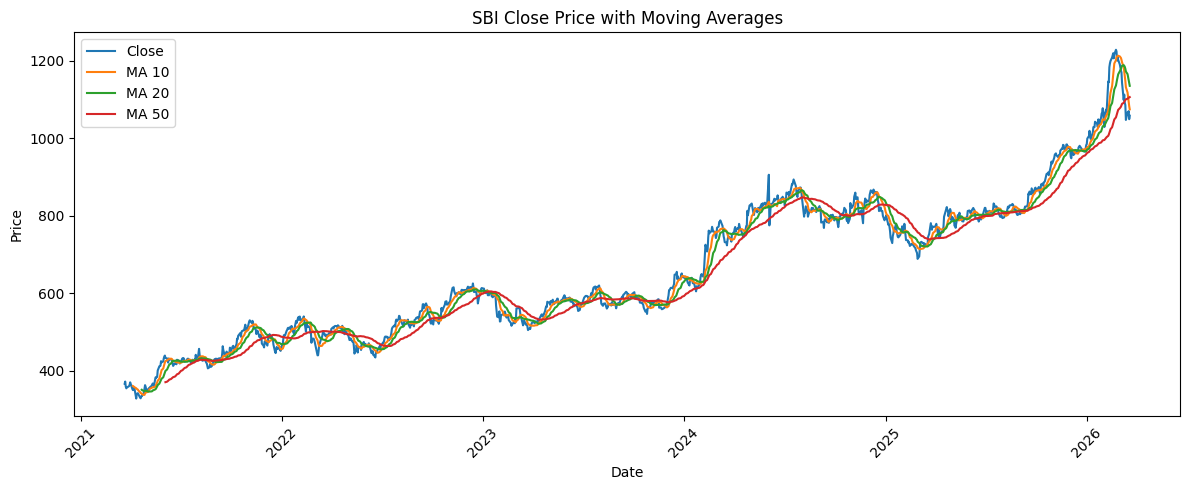

In [3]:
plt.figure()
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["ma_10"], label="MA 10")
plt.plot(df["Date"], df["ma_20"], label="MA 20")
plt.plot(df["Date"], df["ma_50"], label="MA 50")
plt.title("SBI Close Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# RSI Visualization

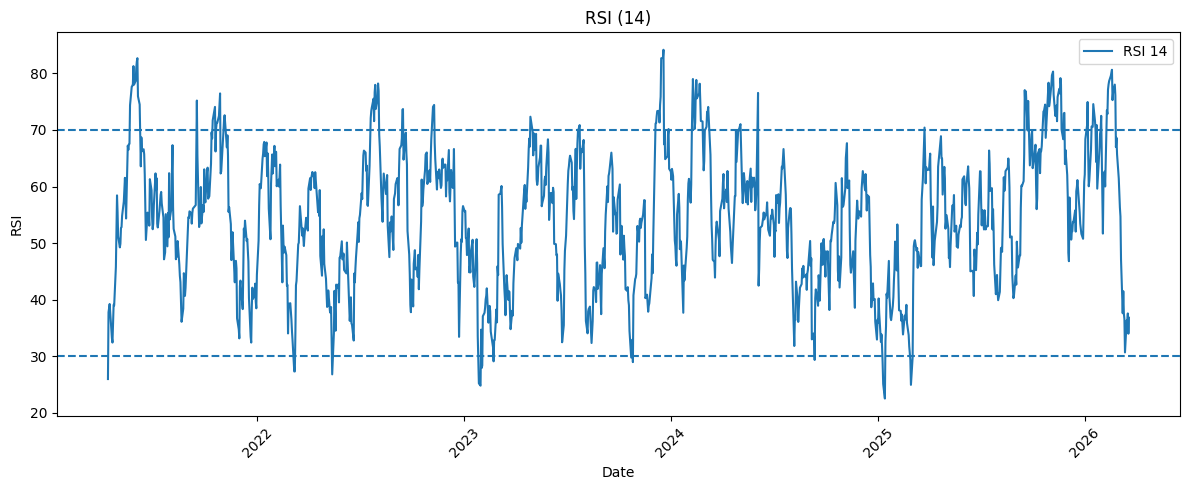

In [4]:
plt.figure()
plt.plot(df["Date"], df["rsi_14"], label="RSI 14")
plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")
plt.title("RSI (14)")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# volatility trends

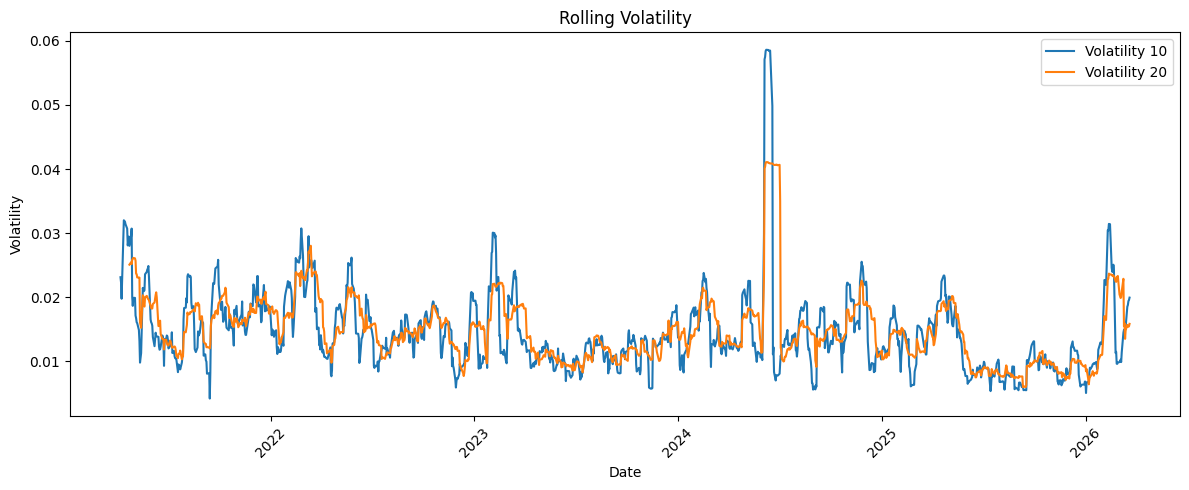

In [5]:
plt.figure()
plt.plot(df["Date"], df["volatility_10"], label="Volatility 10")
plt.plot(df["Date"], df["volatility_20"], label="Volatility 20")
plt.title("Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Future Return Distribution

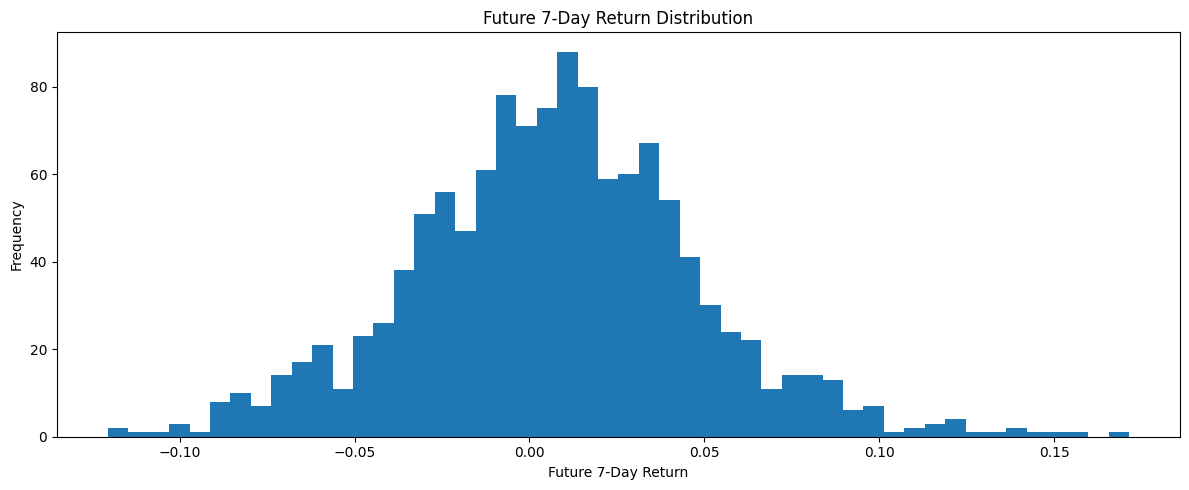

In [6]:
plt.figure()
plt.hist(df["future_return_7d"].dropna(), bins=50)
plt.title("Future 7-Day Return Distribution")
plt.xlabel("Future 7-Day Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Target Distribution

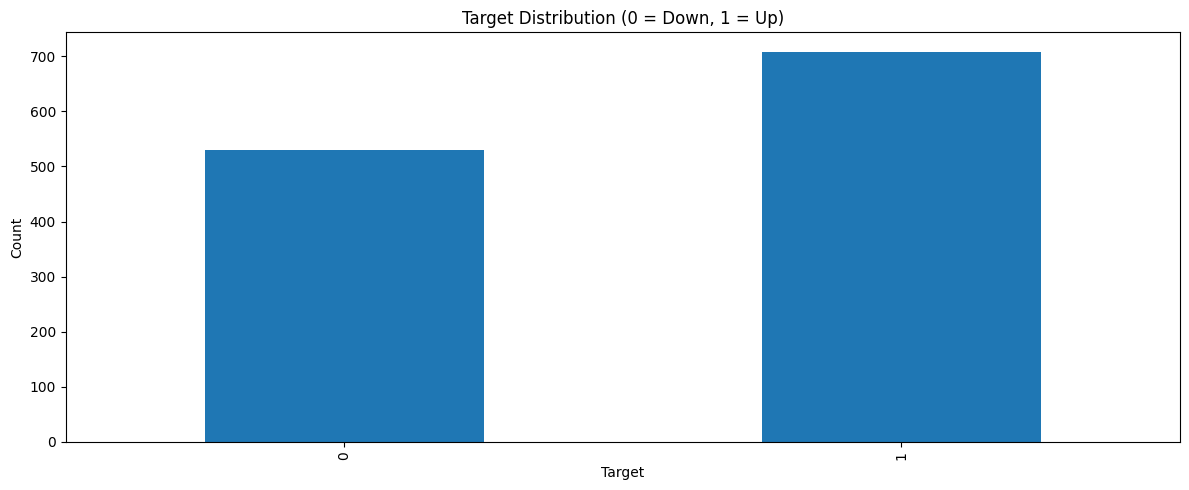

In [7]:
plt.figure()
df["target_up_7d"].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution (0 = Down, 1 = Up)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Relative return Vs target Scatter

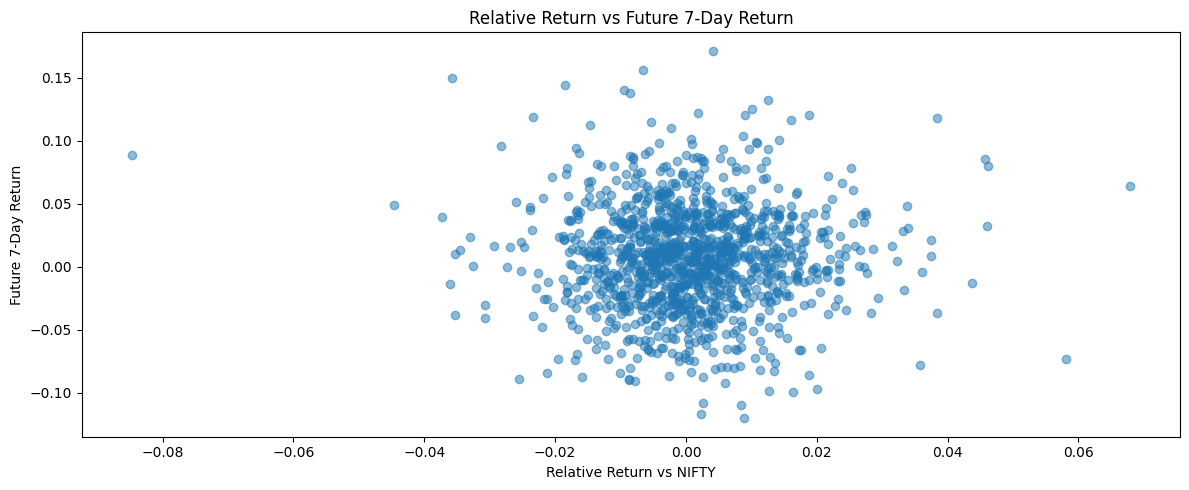

In [8]:
plt.figure()
plt.scatter(df["relative_return_vs_nifty"], df["future_return_7d"], alpha=0.5)
plt.title("Relative Return vs Future 7-Day Return")
plt.xlabel("Relative Return vs NIFTY")
plt.ylabel("Future 7-Day Return")
plt.tight_layout()
plt.show()

# Correlation

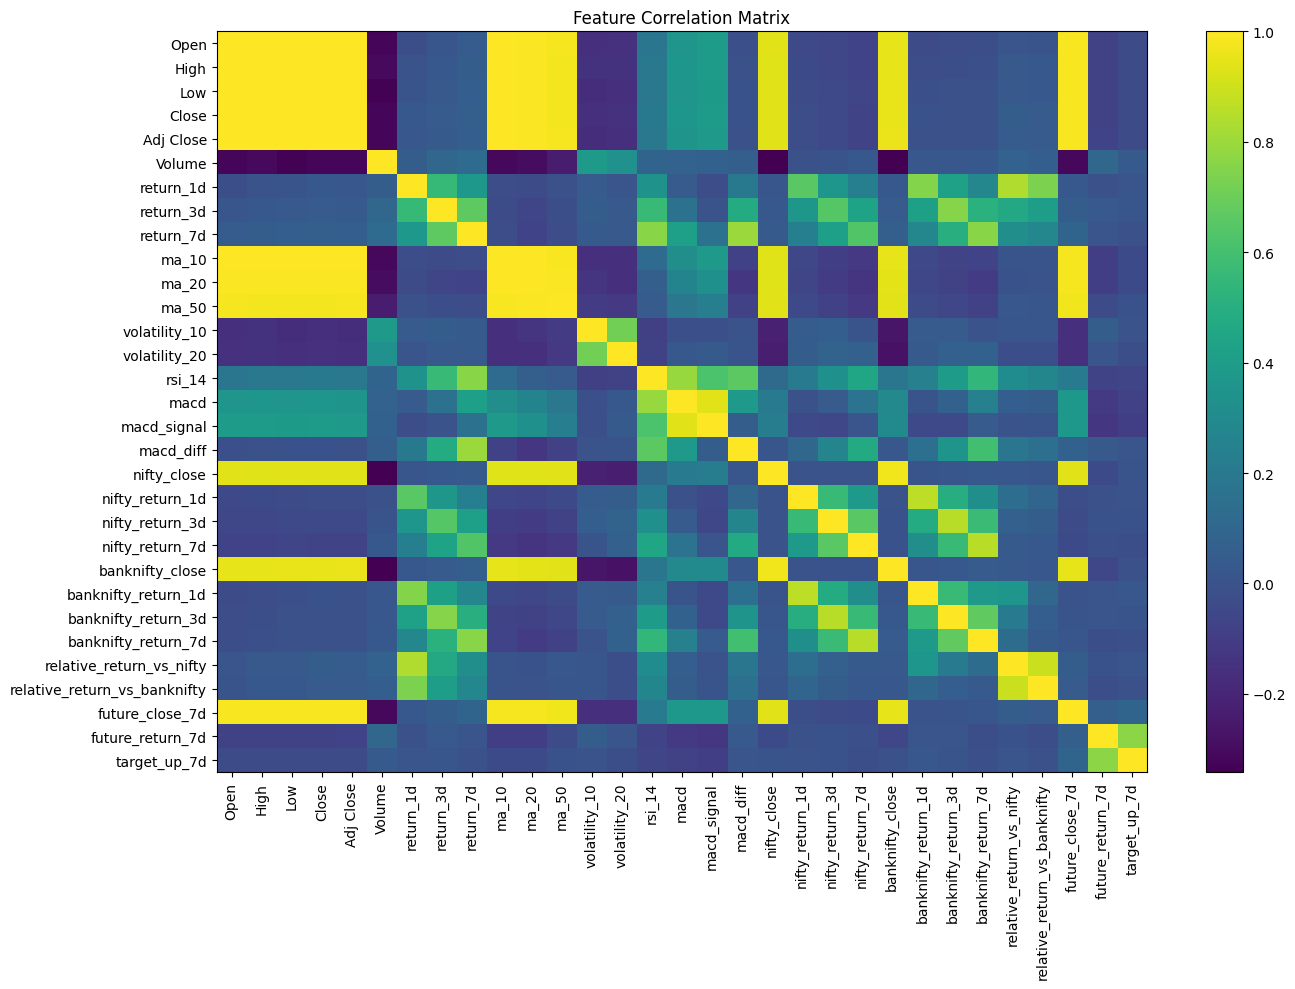

In [9]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14, 10))
plt.imshow(corr, aspect="auto")
plt.title("Feature Correlation Matrix")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

# top Correlations with target

In [10]:
target_corr = numeric_df.corr()["target_up_7d"].sort_values(ascending=False)

print("Top positive correlations with target:")
print(target_corr.head(10))

print("\nTop negative correlations with target:")
print(target_corr.tail(10))

Top positive correlations with target:
target_up_7d                1.000000
future_return_7d            0.766910
future_close_7d             0.089664
Volume                      0.038183
banknifty_return_1d         0.024801
return_3d                   0.019576
macd_diff                   0.013372
relative_return_vs_nifty    0.012460
return_1d                   0.010053
banknifty_return_3d         0.008481
Name: target_up_7d, dtype: float64

Top negative correlations with target:
Adj Close     -0.028201
High          -0.033953
Close         -0.034273
Open          -0.034558
Low           -0.034584
ma_20         -0.040677
ma_10         -0.043161
rsi_14        -0.062873
macd          -0.084354
macd_signal   -0.093628
Name: target_up_7d, dtype: float64
